In [1]:
import os
from datetime import date, timedelta

import numpy as np
import pandas as pd
try:
    import yfinance as yf
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance"])
    import yfinance as yf

# --------- Config ---------
SYMBOLS = [
    "^GSPC", "SPY",          # US index + ETF
    "BTC-USD", "ETH-USD",    # crypto
    "^NSEI", "^NSEBANK",     # India indices
    "RELIANCE.NS", "TCS.NS", # India stocks
    "EURUSD=X", "USDINR=X",  # FX
    "GC=F", "CL=F",          # commodities
    "^VIX"                   # volatility index
]

TODAY = date.today()
START = (TODAY - timedelta(days=365 * 20 + 5 * 6)).isoformat()  # ~20y with leap buffer
END = TODAY.isoformat()
INTERVAL = "1d"
RAW_DIR = "data/raw"
os.makedirs(RAW_DIR, exist_ok=True)


def download_one(symbol: str,
                 start: str,
                 end: str,
                 interval: str = "1d",
                 auto_adjust: bool = False) -> dict:
    """Download one symbol from Yahoo, keep OHLCV, save to CSV, return meta."""
    df = yf.download(
        symbol,
        start=start,
        end=end,
        interval=interval,
        auto_adjust=auto_adjust,
        progress=False,
        threads=False,
    )

    if df.empty:
        raise RuntimeError(f"No data for {symbol}")

    cols = [c for c in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
            if c in df.columns]
    df = df[cols].copy()
    df.index.name = "Date"

    fname = os.path.join(
        RAW_DIR,
        f"{symbol.replace('^', '')}_{start}_to_{end}_{interval}.csv",
    )
    df.to_csv(fname)

    return {
        "symbol": symbol,
        "rows": len(df),
        "start": df.index.min().strftime("%Y-%m-%d"),
        "end": df.index.max().strftime("%Y-%m-%d"),
        "columns": cols,
        "path": fname,
    }


meta = []
for sym in SYMBOLS:
    info = download_one(sym, START, END, INTERVAL, auto_adjust=False)
    meta.append(info)

print("Downloaded datasets:")
for m in meta:
    print(f" - {m['symbol']:>7} | {m['rows']:5d} rows "
          f"| {m['start']} → {m['end']} | {m['columns']} | {m['path']}")


Downloaded datasets:
 -   ^GSPC |  5047 rows | 2005-12-19 → 2026-01-12 | ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] | data/raw\GSPC_2005-12-19_to_2026-01-13_1d.csv
 -     SPY |  5047 rows | 2005-12-19 → 2026-01-12 | ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] | data/raw\SPY_2005-12-19_to_2026-01-13_1d.csv
 - BTC-USD |  4136 rows | 2014-09-17 → 2026-01-12 | ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] | data/raw\BTC-USD_2005-12-19_to_2026-01-13_1d.csv
 - ETH-USD |  2987 rows | 2017-11-09 → 2026-01-12 | ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] | data/raw\ETH-USD_2005-12-19_to_2026-01-13_1d.csv
 -   ^NSEI |  4495 rows | 2007-09-17 → 2026-01-12 | ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] | data/raw\NSEI_2005-12-19_to_2026-01-13_1d.csv
 - ^NSEBANK |  4219 rows | 2007-09-17 → 2026-01-12 | ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] | data/raw\NSEBANK_2005-12-19_to_2026-01-13_1d.csv
 - RELIANCE.NS |  4953 rows | 2005

In [2]:
import json

RAW_DIR = "data/raw"
PROC_DIR = "data/processed"
SPLIT_DIR = "data/splits"
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)


def latest_raw(prefix: str) -> str:
    """Pick the latest raw CSV for a given symbol prefix."""
    files = [f for f in os.listdir(RAW_DIR)
             if f.startswith(prefix + "_") and f.endswith(".csv")]
    if not files:
        raise FileNotFoundError(f"No raw file for prefix={prefix}")
    files.sort()
    return os.path.join(RAW_DIR, files[-1])


gspc_raw = latest_raw("GSPC")
spy_raw = latest_raw("SPY")
print("Found raw files:\n -", gspc_raw, "\n -", spy_raw)


def load_yahoo_csv(path: str) -> pd.DataFrame:
    """
    Load Yahoo CSV.
    1) Try standard 'Date' column or index.
    2) If that fails, handle multi-row header variant.
    Always return Date-indexed OHLCV with numeric values.
    """
    # Try normal case
    try:
        df = pd.read_csv(path)
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            df = df.set_index("Date").sort_index()
        else:
            df = pd.read_csv(path, index_col=0)
            df.index = pd.to_datetime(df.index, errors="coerce")
            df = df.sort_index()

        if not any(c in df.columns for c in
                   ["Open", "High", "Low", "Close", "Adj Close", "Volume"]):
            raise ValueError("No canonical OHLCV found")

        df = df[~df.index.isna()]
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        cols = [c for c in
                ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
                if c in df.columns]
        return df[cols].dropna(how="all")

    except Exception:
        # Fallback: multi-row header
        raw = pd.read_csv(path, header=None)
        idxs = np.where(raw.iloc[:, 0].astype(str).str.strip() == "Date")[0]
        if len(idxs) == 0:
            raise ValueError(f"Could not find 'Date' header in {path}")
        hdr_idx = int(idxs[0])
        header = raw.iloc[hdr_idx].tolist()
        body = raw.iloc[hdr_idx + 1:].copy()
        body.columns = header

        body["Date"] = pd.to_datetime(body["Date"], errors="coerce")
        body = body.set_index("Date").sort_index()
        for c in body.columns:
            body[c] = pd.to_numeric(body[c], errors="coerce")

        cols = [c for c in
                ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
                if c in body.columns]
        return body[cols].dropna(how="all")


def build_features(df: pd.DataFrame,
                   symbol: str,
                   rsi_window: int = 14) -> pd.DataFrame:
    """
    Create feature panel u_t and multi-horizon targets for forward returns.
    """
    out = df.copy()
    price_col = "Adj Close" if "Adj Close" in out.columns else "Close"
    out = out.rename(columns={price_col: "PX"})

    # One-day log return
    out["ret_1"] = np.log(out["PX"]).diff()

    # Lagged cumulative returns
    out["ret_2"] = out["ret_1"].shift(1).rolling(2).sum()
    out["ret_5"] = out["ret_1"].shift(1).rolling(5).sum()

    # 20-day realized volatility, annualized
    out["vol_20"] = out["ret_1"].rolling(20).std() * np.sqrt(252.0)

    # Moving averages and price/MA gap
    out["ma_10"] = out["PX"].rolling(10).mean()
    out["ma_20"] = out["PX"].rolling(20).mean()
    out["ma_gap"] = out["PX"] / out["ma_20"] - 1.0

    # RSI(14)
    delta = out["PX"].diff()
    gain = delta.clip(lower=0).rolling(rsi_window).mean()
    loss = (-delta.clip(upper=0)).rolling(rsi_window).mean()
    rs = gain / loss.replace(0, np.nan)
    out["rsi_14"] = 100.0 - 100.0 / (1.0 + rs)

    # Volume z-score over 60 days
    if "Volume" in out.columns:
        vol_mean = out["Volume"].rolling(60).mean()
        vol_std = out["Volume"].rolling(60).std()
        out["vol_z"] = (out["Volume"] - vol_mean) / vol_std
    else:
        out["vol_z"] = np.nan

    # Day of week
    out["dow"] = out.index.dayofweek

    # Forward log-return targets
    out["target_h1"] = out["ret_1"].shift(-1)
    out["target_h5"] = out["ret_1"].rolling(5).sum().shift(-5)
    out["target_h20"] = out["ret_1"].rolling(20).sum().shift(-20)

    out = out.dropna().copy()
    out.insert(0, "Symbol", symbol)
    return out


def process_symbol(raw_path: str, symbol: str) -> str:
    raw = load_yahoo_csv(raw_path)
    feats = build_features(raw, symbol)
    out_path = os.path.join(PROC_DIR, f"{symbol}_features.csv")
    feats.to_csv(out_path)
    print(f"Saved {symbol} features: {out_path} | "
          f"rows={len(feats)} | {feats.index.min().date()} → {feats.index.max().date()}")
    return out_path


gspc_proc = process_symbol(gspc_raw, "GSPC")
spy_proc = process_symbol(spy_raw, "SPY")


Found raw files:
 - data/raw\GSPC_2005-12-19_to_2026-01-13_1d.csv 
 - data/raw\SPY_2005-12-19_to_2026-01-13_1d.csv


C:\Users\shrey\AppData\Local\Temp\ipykernel_21692\3028751634.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


Saved GSPC features: data/processed\GSPC_features.csv | rows=4968 | 2006-03-16 → 2025-12-11


C:\Users\shrey\AppData\Local\Temp\ipykernel_21692\3028751634.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


Saved SPY features: data/processed\SPY_features.csv | rows=4967 | 2006-03-16 → 2025-12-11


In [3]:
def read_proc(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.set_index("Date")
    else:
        df = pd.read_csv(path, index_col=0)
        df.index = pd.to_datetime(df.index, errors="coerce")
    df = df.sort_index()
    return df[~df.index.isna()]


gspc = read_proc(gspc_proc)
spy = read_proc(spy_proc)

TRAIN_DAYS = 252 * 10  # ~10 years
TEST_DAYS = 252        # ~1 year
STEP_DAYS = 252

common_idx = gspc.index.intersection(spy.index).sort_values()

folds = []
start_ix = 0
while True:
    tr_start = start_ix
    tr_end = tr_start + TRAIN_DAYS
    te_end = tr_end + TEST_DAYS
    if te_end > len(common_idx):
        break

    folds.append({
        "train": {
            "start": common_idx[tr_start].strftime("%Y-%m-%d"),
            "end":   common_idx[tr_end - 1].strftime("%Y-%m-%d"),
        },
        "test": {
            "start": common_idx[tr_end].strftime("%Y-%m-%d"),
            "end":   common_idx[te_end - 1].strftime("%Y-%m-%d"),
        },
        "details": {
            "train_days": TRAIN_DAYS,
            "test_days": TEST_DAYS,
        },
    })

    start_ix += STEP_DAYS

splits_path = os.path.join(SPLIT_DIR, "splits.json")
with open(splits_path, "w") as f:
    json.dump({
        "index": "intersection(GSPC,SPY)",
        "train_days": TRAIN_DAYS,
        "test_days": TEST_DAYS,
        "step_days": STEP_DAYS,
        "folds": folds,
    }, f, indent=2)

print(f"Walk-forward splits: {len(folds)} folds → {splits_path}")
if folds:
    print("Example fold[0]:", folds[0])


Walk-forward splits: 9 folds → data/splits\splits.json
Example fold[0]: {'train': {'start': '2006-03-16', 'end': '2016-03-21'}, 'test': {'start': '2016-03-22', 'end': '2017-03-21'}, 'details': {'train_days': 2520, 'test_days': 252}}


In [4]:
from sklearn.preprocessing import StandardScaler

PROC_DIR = "data/processed"
SPLIT_DIR = "data/splits"

def read_proc_again(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.set_index("Date")
    else:
        df = pd.read_csv(path, index_col=0)
        df.index = pd.to_datetime(df.index, errors="coerce")
    df = df.sort_index()
    return df[~df.index.isna()]


gspc = read_proc_again(os.path.join(PROC_DIR, "GSPC_features.csv"))
spy = read_proc_again(os.path.join(PROC_DIR, "SPY_features.csv"))

idx = gspc.index.intersection(spy.index).sort_values()
gspc = gspc.loc[idx]
spy = spy.loc[idx]

print("=== Quick EDA ===")
for sym, df in [("GSPC", gspc), ("SPY", spy)]:
    print(f"{sym}: rows={len(df)}, cols={len(df.columns)}, "
          f"range={df.index.min().date()} → {df.index.max().date()}, "
          f"NaN frac={df.isna().mean().mean():.4f}")

TARGET_COLS = ["target_h1", "target_h5", "target_h20"]
FEATURE_COLS = [
    "ret_1", "ret_2", "ret_5",
    "vol_20", "ma_10", "ma_20", "ma_gap",
    "rsi_14", "vol_z", "dow",
]

missing = [c for c in FEATURE_COLS if c not in gspc.columns or c not in spy.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

with open(os.path.join(SPLIT_DIR, "splits.json"), "r") as f:
    split_plan = json.load(f)
folds = split_plan["folds"]
print(f"\nMaterializing {len(folds)} folds with leakage-safe scalers...")


def make_fold(k: int,
              df_left: pd.DataFrame,
              df_right: pd.DataFrame,
              save_dir: str) -> dict:
    """Use SPY (df_right) as primary dataset and scale per-fold."""
    fold = folds[k]
    tr_s, tr_e = fold["train"]["start"], fold["train"]["end"]
    te_s, te_e = fold["test"]["start"], fold["test"]["end"]

    tr = df_right.loc[tr_s:tr_e].copy()
    te = df_right.loc[te_s:te_e].copy()

    tr = tr.dropna(subset=TARGET_COLS)
    te = te.dropna(subset=TARGET_COLS)

    scaler = StandardScaler()
    tr_X = scaler.fit_transform(tr[FEATURE_COLS].values)
    te_X = scaler.transform(te[FEATURE_COLS].values)

    zcols = [f"z_{c}" for c in FEATURE_COLS]
    tr_out = pd.DataFrame(tr_X, index=tr.index, columns=zcols)
    te_out = pd.DataFrame(te_X, index=te.index, columns=zcols)

    for c in TARGET_COLS:
        tr_out[c] = tr[c].values
        te_out[c] = te[c].values

    tr_out["Symbol"] = tr["Symbol"].values
    te_out["Symbol"] = te["Symbol"].values

    os.makedirs(save_dir, exist_ok=True)
    tr_out.to_csv(os.path.join(save_dir, "train.csv"))
    te_out.to_csv(os.path.join(save_dir, "test.csv"))

    scaler_meta = {
        "features": FEATURE_COLS,
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "train_start": tr_s,
        "train_end": tr_e,
        "test_start": te_s,
        "test_end": te_e,
    }
    with open(os.path.join(save_dir, "scaler.json"), "w") as f:
        json.dump(scaler_meta, f, indent=2)

    return {
        "k": k,
        "train_rows": len(tr_out),
        "test_rows": len(te_out),
        "train_range": (tr_s, tr_e),
        "test_range": (te_s, te_e),
    }


materialized = []
for k in range(len(folds)):
    fold_dir = os.path.join(SPLIT_DIR, f"fold_{k}")
    info = make_fold(k, gspc, spy, fold_dir)
    materialized.append(info)
    print(f"Fold {k}: train={info['train_rows']:4d} rows, "
          f"test={info['test_rows']:4d} rows | "
          f"{info['train_range'][0]}→{info['train_range'][1]} | "
          f"{info['test_range'][0]}→{info['test_range'][1]}")

print("\nDone. Example paths:")
if materialized:
    print(" -", os.path.join(SPLIT_DIR, "fold_0", "train.csv"))
    print(" -", os.path.join(SPLIT_DIR, "fold_0", "test.csv"))


=== Quick EDA ===
GSPC: rows=4967, cols=20, range=2006-03-16 → 2025-12-11, NaN frac=0.0000
SPY: rows=4967, cols=20, range=2006-03-16 → 2025-12-11, NaN frac=0.0000

Materializing 9 folds with leakage-safe scalers...
Fold 0: train=2520 rows, test= 252 rows | 2006-03-16→2016-03-21 | 2016-03-22→2017-03-21
Fold 1: train=2520 rows, test= 252 rows | 2007-03-19→2017-03-21 | 2017-03-22→2018-03-21
Fold 2: train=2520 rows, test= 252 rows | 2008-03-18→2018-03-21 | 2018-03-22→2019-03-22
Fold 3: train=2520 rows, test= 252 rows | 2009-03-18→2019-03-22 | 2019-03-25→2020-03-23
Fold 4: train=2520 rows, test= 252 rows | 2010-03-19→2020-03-23 | 2020-03-24→2021-03-23
Fold 5: train=2520 rows, test= 252 rows | 2011-03-18→2021-03-23 | 2021-03-24→2022-03-22
Fold 6: train=2520 rows, test= 252 rows | 2012-03-19→2022-03-22 | 2022-03-23→2023-03-23
Fold 7: train=2520 rows, test= 252 rows | 2013-03-21→2023-03-23 | 2023-03-24→2024-03-25
Fold 8: train=2520 rows, test= 252 rows | 2014-03-21→2024-03-25 | 2024-03-26→2025

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

SPLIT_DIR = "data/splits"
FOLD = 0
fold_dir = os.path.join(SPLIT_DIR, f"fold_{FOLD}")

train_path = os.path.join(fold_dir, "train.csv")
test_path = os.path.join(fold_dir, "test.csv")
assert os.path.exists(train_path) and os.path.exists(test_path)

train = pd.read_csv(train_path, index_col=0, parse_dates=True)
test = pd.read_csv(test_path, index_col=0, parse_dates=True)

FEATURE_COLS = [c for c in train.columns if c.startswith("z_")]
TARGETS = ["target_h1", "target_h5", "target_h20"]

X_tr = train[FEATURE_COLS].values
X_te = test[FEATURE_COLS].values

metrics = []
pred_df = pd.DataFrame(index=test.index)

for tgt in TARGETS:
    y_tr = train[tgt].values
    y_te = test[tgt].values

    model = Ridge(alpha=1.0, fit_intercept=True, random_state=0)
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_hat))
    mae = mean_absolute_error(y_te, y_hat)
    dir_acc = np.mean(np.sign(y_hat) == np.sign(y_te))

    metrics.append({"target": tgt,
                    "rmse": rmse,
                    "mae": mae,
                    "dir_acc": dir_acc})

    pred_df[f"pred_{tgt}"] = y_hat
    pred_df[f"true_{tgt}"] = y_te

out_pred_path = os.path.join(fold_dir, "preds_baseline.csv")
pred_df.to_csv(out_pred_path)

print("=== Fold 0 — Ridge Readout Baseline ===")
print(f"Train rows: {len(train):,} | Test rows: {len(test):,}")
print(f"Features: {len(FEATURE_COLS)} → {FEATURE_COLS[:5]} ...")

print("\nMetrics (test set):")
for m in metrics:
    print(f" - {m['target']:<10} RMSE={m['rmse']:.6f} "
          f"| MAE={m['mae']:.6f} | DirAcc={m['dir_acc']:.3f}")

print(f"\nSaved predictions → {out_pred_path}")


=== Fold 0 — Ridge Readout Baseline ===
Train rows: 2,520 | Test rows: 252
Features: 10 → ['z_ret_1', 'z_ret_2', 'z_ret_5', 'z_vol_20', 'z_ma_10'] ...

Metrics (test set):
 - target_h1  RMSE=0.006359 | MAE=0.004508 | DirAcc=0.524
 - target_h5  RMSE=0.013013 | MAE=0.010020 | DirAcc=0.476
 - target_h20 RMSE=0.023451 | MAE=0.018768 | DirAcc=0.556

Saved predictions → data/splits\fold_0\preds_baseline.csv


=== Test Metrics (Fold 0) ===
    target     rmse      mae        r2  dir_acc
 target_h1 0.006359 0.004508 -0.011084 0.523810
 target_h5 0.013013 0.010020 -0.104224 0.476190
target_h20 0.023451 0.018768 -0.272823 0.555556

Residual summary (h=1):
count    252.000000
mean       0.000607
std        0.006342
min       -0.035005
25%       -0.002471
50%        0.000435
75%        0.004384
max        0.021451
dtype: float64


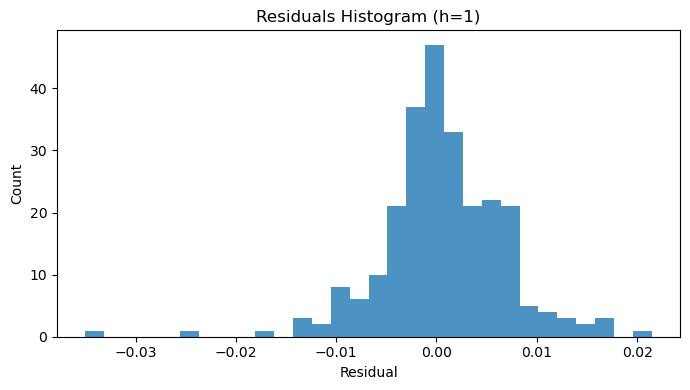

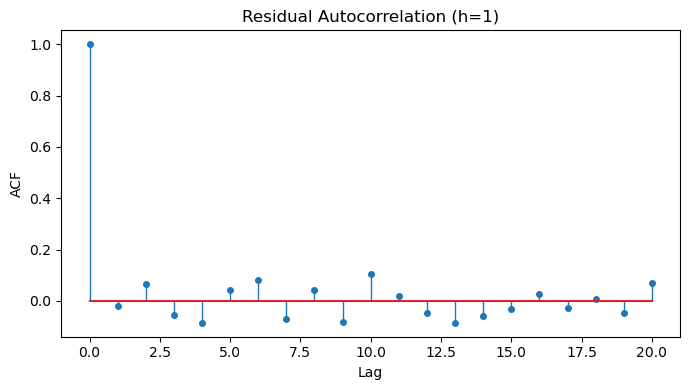


=== Simple Backtest (h=1) ===
Avg daily PnL: 0.000200
Vol (std): 0.006347
Sharpe: 0.500
Hit ratio: 0.524
Turnover: 0.726 trades/day


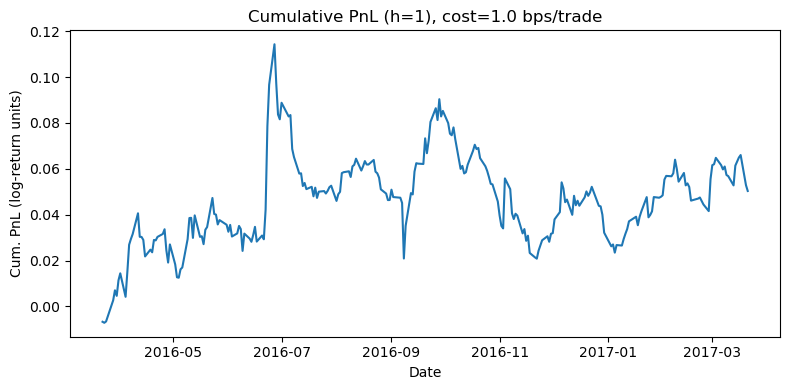


Top features by |Ridge coef| (h=1):
 feature      coef  abs_coef
 z_ret_1 -0.000958  0.000958
z_ma_gap -0.000883  0.000883
z_vol_20 -0.000625  0.000625
 z_vol_z -0.000596  0.000596
 z_ret_5 -0.000457  0.000457
   z_dow -0.000335  0.000335
z_rsi_14  0.000273  0.000273
 z_ma_20 -0.000188  0.000188
 z_ret_2 -0.000155  0.000155
 z_ma_10 -0.000068  0.000068

Saved:
 - data/splits\fold_0\analysis_summary.csv
 - data/splits\fold_0\analysis_summary.json


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

preds = pd.read_csv(out_pred_path, index_col=0, parse_dates=True)

def basic_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    dir_acc = float(np.mean(np.sign(y_pred) == np.sign(y_true)))
    return {"rmse": rmse, "mae": mae, "r2": r2, "dir_acc": dir_acc}

targets = ["target_h1", "target_h5", "target_h20"]
rows = []
for tgt in targets:
    y_true = preds[f"true_{tgt}"].values
    y_pred = preds[f"pred_{tgt}"].values
    rows.append({"target": tgt, **basic_metrics(y_true, y_pred)})

metrics_df = pd.DataFrame(rows)
print("=== Test Metrics (Fold 0) ===")
print(metrics_df.to_string(index=False))

# Residuals for h=1
tgt = "target_h1"
y_true = preds[f"true_{tgt}"].values
y_pred = preds[f"pred_{tgt}"].values
resid = y_true - y_pred

print("\nResidual summary (h=1):")
print(pd.Series(resid).describe())

plt.figure(figsize=(7, 4))
plt.hist(resid, bins=30, alpha=0.8)
plt.title("Residuals Histogram (h=1)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


def acf(x, nlags=20):
    x = np.asarray(x)
    x = x - x.mean()
    denom = np.dot(x, x)
    out = [1.0]
    for k in range(1, nlags + 1):
        out.append(np.dot(x[:-k], x[k:]) / denom if denom > 0 else np.nan)
    return np.array(out)


lags = 20
acf_vals = acf(resid, nlags=lags)

plt.figure(figsize=(7, 4))
try:
    markerline, stemlines, baseline = plt.stem(range(lags + 1), acf_vals)
    plt.setp(stemlines, linewidth=1.0)
    plt.setp(markerline, markersize=4)
except TypeError:
    plt.bar(range(lags + 1), acf_vals, width=0.6)
plt.title("Residual Autocorrelation (h=1)")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

# Simple sign-based backtest for h=1
cost_per_trade = 0.0001  # 1 bp
pos = np.sign(y_pred)
pos_change = np.abs(np.diff(pos, prepend=0))
pnl = pos * y_true - cost_per_trade * pos_change

cum_pnl = pnl.cumsum()
ann_factor = np.sqrt(252.0)
sharpe = pnl.mean() / (pnl.std() + 1e-12) * ann_factor
hit_ratio = float(np.mean((pos * y_true) > 0))

print("\n=== Simple Backtest (h=1) ===")
print(f"Avg daily PnL: {pnl.mean():.6f}")
print(f"Vol (std): {pnl.std():.6f}")
print(f"Sharpe: {sharpe:.3f}")
print(f"Hit ratio: {hit_ratio:.3f}")
print(f"Turnover: {pos_change.mean():.3f} trades/day")

plt.figure(figsize=(8, 4))
plt.plot(preds.index, cum_pnl)
plt.title(f"Cumulative PnL (h=1), cost={cost_per_trade*1e4:.1f} bps/trade")
plt.xlabel("Date")
plt.ylabel("Cum. PnL (log-return units)")
plt.tight_layout()
plt.show()

# Ridge coefficient inspection on train
FEATURE_COLS = [c for c in train.columns if c.startswith("z_")]
X_tr = train[FEATURE_COLS].values
y_tr = train["target_h1"].values

ridge = Ridge(alpha=1.0, fit_intercept=True, random_state=0)
ridge.fit(X_tr, y_tr)

coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coef": ridge.coef_,
    "abs_coef": np.abs(ridge.coef_),
}).sort_values("abs_coef", ascending=False)

print("\nTop features by |Ridge coef| (h=1):")
print(coef_df.head(10).to_string(index=False))

# Save summary
summary = {
    "metrics": metrics_df.round(6).to_dict(orient="records"),
    "backtest": {
        "avg_daily_pnl": float(np.round(pnl.mean(), 6)),
        "vol": float(np.round(pnl.std(), 6)),
        "sharpe": float(np.round(sharpe, 3)),
        "hit_ratio": float(np.round(hit_ratio, 3)),
        "turnover": float(np.round(pos_change.mean(), 3)),
        "cost_per_trade": cost_per_trade,
    },
    "top_coef_h1": coef_df.head(10).to_dict(orient="records"),
}

metrics_csv = os.path.join(fold_dir, "analysis_summary.csv")
metrics_df.to_csv(metrics_csv, index=False)

with open(os.path.join(fold_dir, "analysis_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSaved:\n - {metrics_csv}\n - {os.path.join(fold_dir, 'analysis_summary.json')}")
